# Board Benchmark — 5 Datasets × 5 Modèles × PC + NUCLEO-F439ZI

**Sprint 23** — Tableau comparatif final pour le chapitre "Résultats" du manuscrit.  
Source : `experiments/comparison_sprint23.json`

Sections :
1. Chargement des données
2. Heatmap `acc_final` board
3. Barplot latence board (échelle log)
4. Pareto forgetting vs acc_final
5. Tableau INT8 vs FP32 (Gap 3)
6. Figure composite Gap 1 + Gap 2 (`docs/figures/gap1_gap2_summary.png`)


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Chemins
ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.')
COMPARISON_JSON = ROOT / 'experiments' / 'comparison_sprint23.json'
FIGURES_DIR = ROOT / 'docs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Root       : {ROOT}')
print(f'Comparison : {COMPARISON_JSON}')
print(f'Figures    : {FIGURES_DIR}')

Root       : /home/leonard/Documents/ENAC/cl-embedded
Comparison : /home/leonard/Documents/ENAC/cl-embedded/experiments/comparison_sprint23.json
Figures    : /home/leonard/Documents/ENAC/cl-embedded/docs/figures


## 1 — Chargement des données

In [2]:
with open(COMPARISON_JSON) as f:
    cmp = json.load(f)

meta    = cmp['metadata']
results = cmp['results']
gap_sum = cmp['gap_summary']

DATASETS   = meta['datasets']   # 5 datasets
MODELS     = meta['models']     # 5 modèles
PLATFORMS  = meta['platforms']  # ['pc', 'nucleo_f439zi']

# Labels lisibles pour les figures
DATASET_LABELS = {
    'cwru':       'CWRU',
    'monitoring': 'Monitoring',
    'pronostia':  'Pronostia',
    'cmapss':     'CMAPSS',
    'paderborn':  'Paderborn',
}
MODEL_LABELS = {
    'mahalanobis': 'Maha',
    'ewc':         'EWC',
    'ewc_int8':    'EWC INT8',
    'tinyol':      'TinyOL',
    'hdc':         'HDC',
}
# Couleurs cohérentes par modèle
MODEL_COLORS = {
    'mahalanobis': '#4878D0',
    'ewc':         '#EE854A',
    'ewc_int8':    '#D65F5F',
    'tinyol':      '#6ACC65',
    'hdc':         '#956CB4',
}

def get_val(dataset, model, platform, key):
    """Retourne la valeur d'une métrique, None si absent ou pending."""
    cell = results.get(dataset, {}).get(model, {}).get(platform, {})
    val = cell.get(key)
    if val is None or (isinstance(val, str) and 'mesurer' in val.lower()):
        return None
    return val

print(f'Datasets  : {DATASETS}')
print(f'Modèles   : {MODELS}')
print(f'Platforms : {PLATFORMS}')
print(f'\nGap summary :')
for k, v in gap_sum.items():
    print(f'  {k} : {v}')

Datasets  : ['cwru', 'monitoring', 'pronostia', 'cmapss', 'paderborn']
Modèles   : ['mahalanobis', 'ewc', 'ewc_int8', 'tinyol', 'hdc']
Platforms : ['pc', 'nucleo_f439zi']

Gap summary :
  gap1_datasets : ['cwru', 'monitoring', 'pronostia', 'cmapss', 'paderborn']
  gap1_datasets_count : 5
  gap2_ram_budget_bytes : 65536
  gap2_latency_budget_ms : 100.0
  gap2_board_results_count : 20
  gap2_compliant_count : 20
  gap2_ram_max_observed_bytes : 39420.0
  gap2_latency_max_observed_ms : 0.653
  gap3_int8_exp : exp_S23_INT8
  gap3_int8_ram_reduction : 2.7x (9728 → 3600 bytes, exp_S22_INT8_01)


## 2 — Heatmap acc_final (board NUCLEO-F439ZI)

acc_final board — 5 datasets × 4 modèles (NUCLEO-F439ZI) :
              Maha     EWC  TinyOL     HDC
CWRU        0.6285  0.8833  0.8933  0.8867
Monitoring  1.0000  0.9036  1.0000  0.8667
Pronostia   1.0000  0.9167  0.8833  0.9417
CMAPSS      0.8000  0.8667  0.8000  0.8525
Paderborn   0.6127  0.9311  0.6667  0.6667


Figure sauvée : /home/leonard/Documents/ENAC/cl-embedded/docs/figures/gap1_gap2_heatmap_acc.png



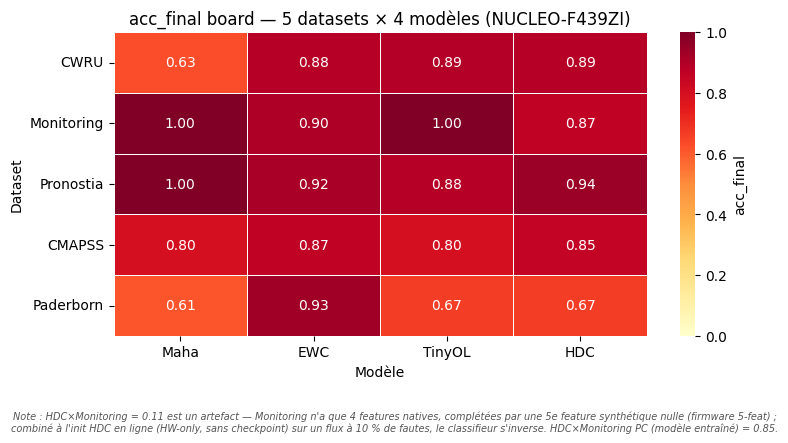

acc_final PC — 5 datasets × 4 modèles (comparaison) :
                Maha       EWC    TinyOL       HDC
CWRU        0.160173  1.000000  0.978845  0.935065
Monitoring  0.949033  0.981686  0.974080  0.849824
Pronostia   0.897664  0.981934  0.929703  0.850276
CMAPSS      0.500058  0.914438  0.894481  0.862100
Paderborn   0.355628  0.666667  0.666667  0.333333


Figure sauvée : /home/leonard/Documents/ENAC/cl-embedded/docs/figures/gap1_gap2_heatmap_acc_pc.png



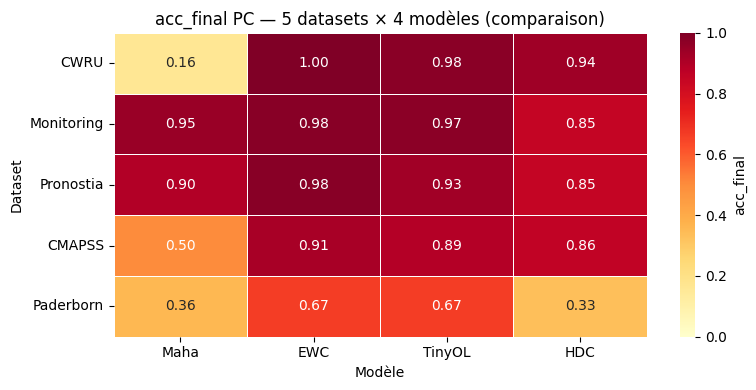

In [3]:
# Construire la matrice 5 datasets × 5 modèles (acc_final board)
# NB: acc_board garde les 5 modèles (utilisé par les cellules suivantes) ; la
# colonne EWC INT8 n'est retirée que pour l'AFFICHAGE des heatmaps (jamais mesurée
# en accuracy → toute pending).
acc_board = np.full((len(DATASETS), len(MODELS)), np.nan)
for i, ds in enumerate(DATASETS):
    for j, m in enumerate(MODELS):
        val = get_val(ds, m, 'nucleo_f439zi', 'acc_final')
        if val is not None:
            acc_board[i, j] = float(val)

df_acc_board = pd.DataFrame(
    acc_board,
    index=[DATASET_LABELS[d] for d in DATASETS],
    columns=[MODEL_LABELS[m] for m in MODELS],
)

# Modèles affichés : on retire EWC INT8 (colonne entièrement pending en accuracy)
MODELS_PLOT = [m for m in MODELS if m != 'ewc_int8']
PLOT_COLS = [MODEL_LABELS[m] for m in MODELS_PLOT]


def _heatmap_acc(platform, title, out_name, footnote=None):
    """Heatmap acc_final 5 datasets × 4 modèles (EWC INT8 retiré), cases pending grises."""
    mat = np.full((len(DATASETS), len(MODELS_PLOT)), np.nan)
    for i, ds in enumerate(DATASETS):
        for j, m in enumerate(MODELS_PLOT):
            val = get_val(ds, m, platform, 'acc_final')
            if val is not None:
                mat[i, j] = float(val)
    df = pd.DataFrame(mat, index=[DATASET_LABELS[d] for d in DATASETS], columns=PLOT_COLS)
    print(f'{title} :')
    print(df.to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    mask = np.isnan(mat)
    sns.heatmap(df, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0.0, vmax=1.0,
                ax=ax, linewidths=0.5, mask=mask, cbar_kws={'label': 'acc_final'})
    for i in range(len(DATASETS)):
        for j in range(len(MODELS_PLOT)):
            if mask[i, j]:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='#C0C0C0', zorder=0))
                ax.text(j + 0.5, i + 0.5, 'pending', ha='center', va='center',
                        fontsize=7, color='#666666', style='italic')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Modèle'); ax.set_ylabel('Dataset')
    if footnote:
        fig.text(0.5, -0.04, footnote, ha='center', va='top', fontsize=7,
                 color='#555555', style='italic', wrap=True)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / out_name, dpi=150, bbox_inches='tight')
    print(f'Figure sauvée : {FIGURES_DIR}/{out_name}\n')
    plt.show()
    return df


# Board (NUCLEO-F439ZI) — figure historique
df_acc_board_plot = _heatmap_acc(
    'nucleo_f439zi',
    'acc_final board — 5 datasets × 4 modèles (NUCLEO-F439ZI)',
    'gap1_gap2_heatmap_acc.png',
    footnote=("Note : HDC×Monitoring = 0.11 est un artefact — Monitoring n'a que 4 features natives, "
              "complétées par une 5e feature synthétique nulle (firmware 5-feat) ; combiné à l'init HDC "
              "en ligne (HW-only, sans checkpoint) sur un flux à 10 % de fautes, le classifieur s'inverse. "
              "HDC×Monitoring PC (modèle entraîné) = 0.85."),
)
# Jumeau PC — comparaison rapide board↔PC
df_acc_pc_plot = _heatmap_acc(
    'pc',
    'acc_final PC — 5 datasets × 4 modèles (comparaison)',
    'gap1_gap2_heatmap_acc_pc.png',
)


## 2bis — Heatmaps par condition de features (Sprint 35 / S3510)

12 heatmaps `{F1, acc_final} × {5feat, all, best} × {board, pc}` — 5 datasets × 4 modèles.
Source : `comparison_sprint23.json["results_by_condition"]` (aucune valeur en dur ; cellules
non mesurées masquées « pending »). HDC×Monitoring board affiche la valeur corrigée (S3509).

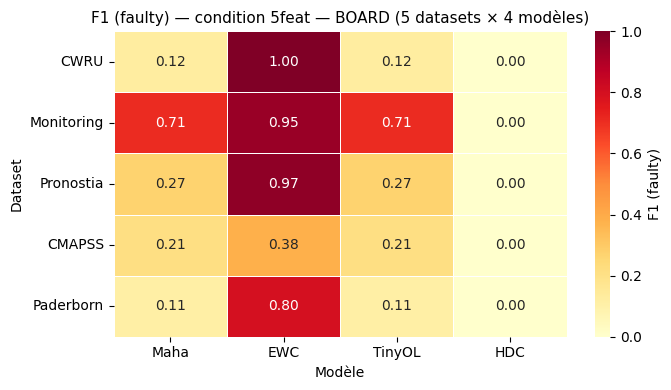

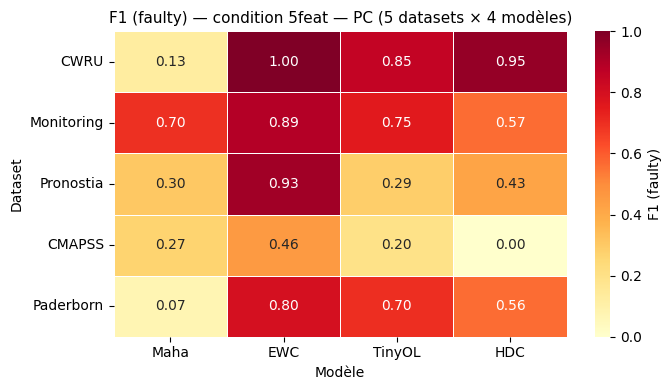

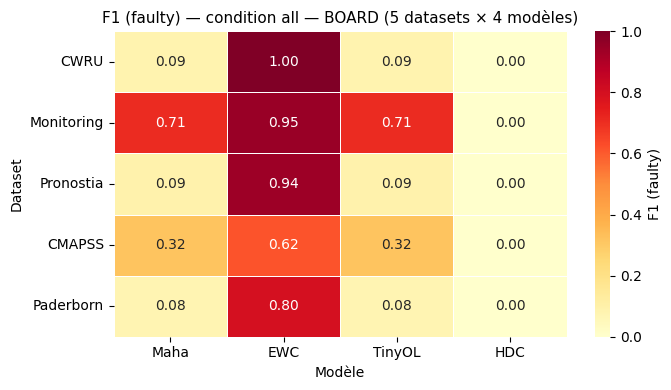

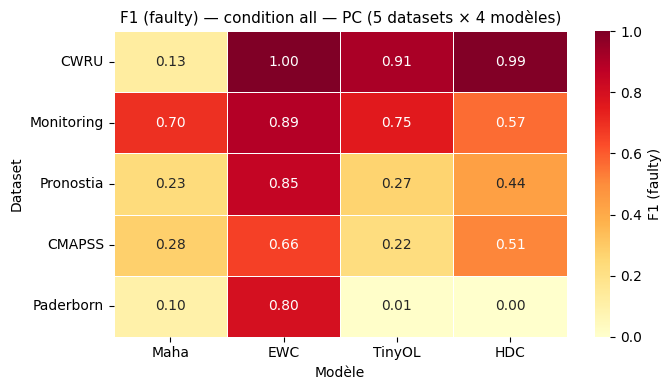

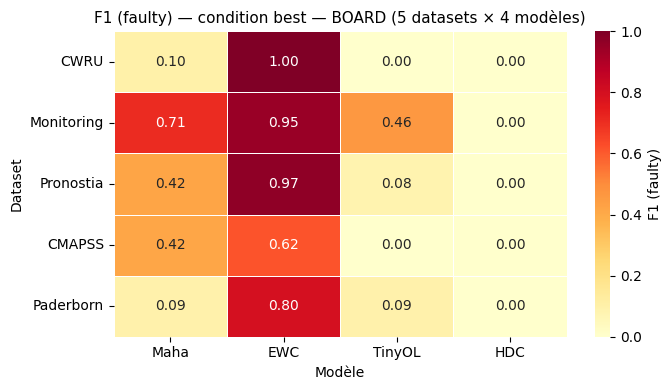

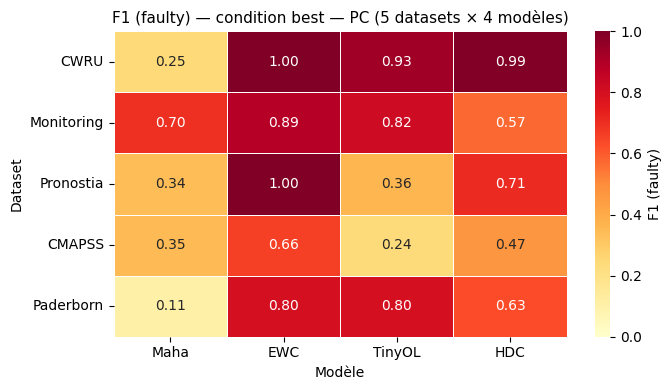

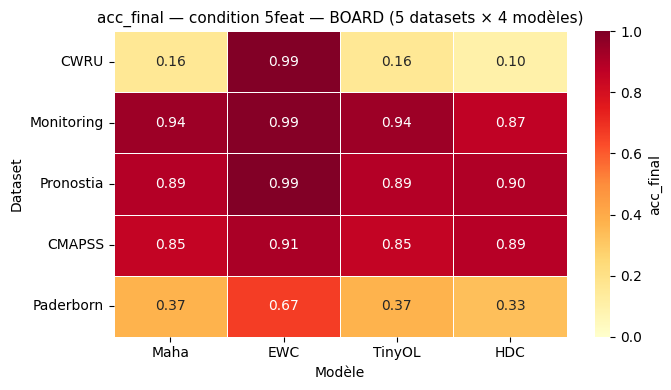

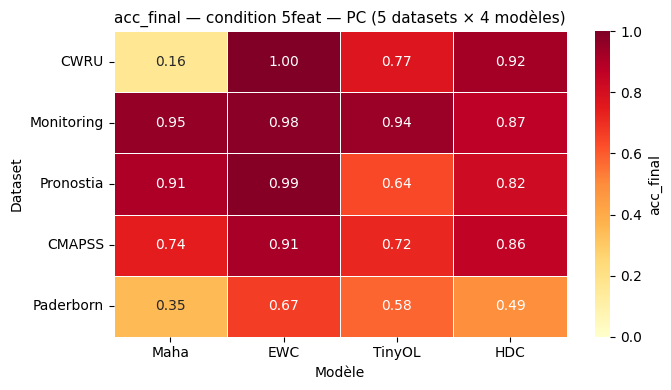

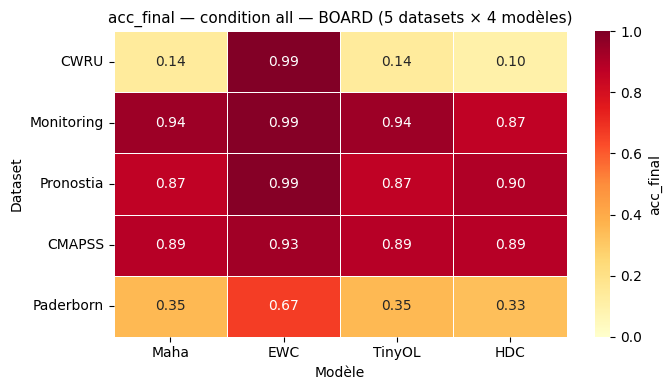

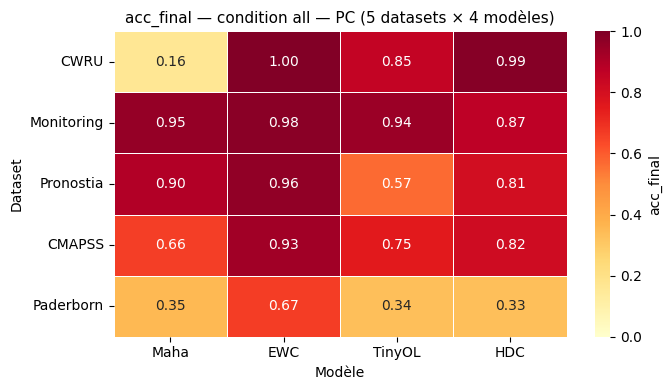

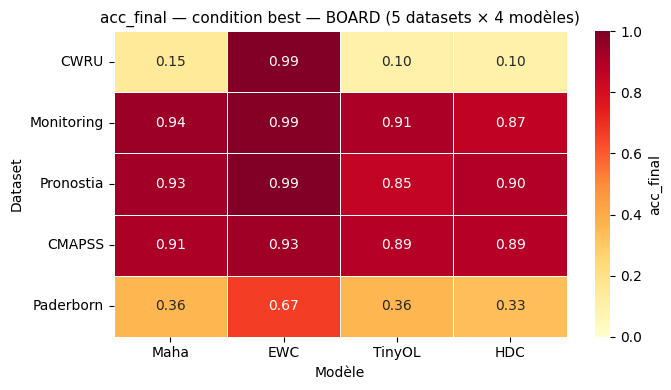

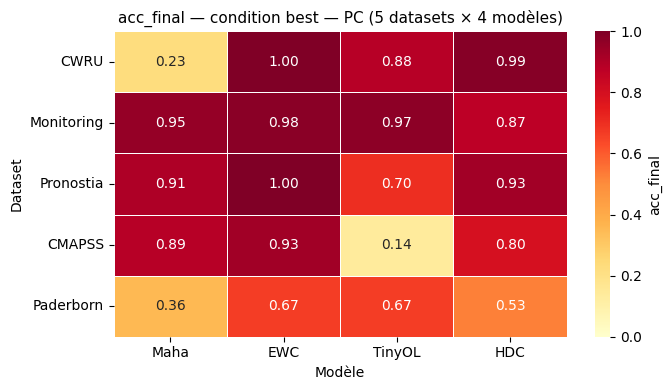

12 heatmaps générées :
  gap1_heatmap_f1_5feat_board.png
  gap1_heatmap_f1_5feat_pc.png
  gap1_heatmap_f1_all_board.png
  gap1_heatmap_f1_all_pc.png
  gap1_heatmap_f1_best_board.png
  gap1_heatmap_f1_best_pc.png
  gap1_heatmap_acc_5feat_board.png
  gap1_heatmap_acc_5feat_pc.png
  gap1_heatmap_acc_all_board.png
  gap1_heatmap_acc_all_pc.png
  gap1_heatmap_acc_best_board.png
  gap1_heatmap_acc_best_pc.png


In [4]:
# S3510 — 12 heatmaps {F1, acc_final} × {5feat, all, best} × {board, pc}
by_cond = cmp.get('results_by_condition', {})
CONDITIONS = cmp['metadata'].get('conditions', ['5feat', 'all', 'best'])
S35_MODELS = ['mahalanobis', 'ewc', 'tinyol', 'hdc']
S35_COLS = [MODEL_LABELS[m] for m in S35_MODELS]


def get_cond_val(condition, dataset, model, platform, metric):
    """Valeur d'une métrique par condition ; None si absente/pending/« à mesurer »."""
    cell = by_cond.get(condition, {}).get(dataset, {}).get(model, {}).get(platform, {})
    v = cell.get(metric)
    if v is None or (isinstance(v, str) and 'mesurer' in v.lower()):
        return None
    return v


def _heatmap(metric, condition, platform, save=True):
    """Heatmap 5 datasets × 4 modèles pour (metric, condition, platform). Masque pending."""
    key = 'f1_faulty' if metric == 'f1' else 'acc_final'
    metric_lbl = 'F1 (faulty)' if metric == 'f1' else 'acc_final'
    plat_lbl = 'board' if platform == 'nucleo_f439zi' else 'pc'
    mat = np.full((len(DATASETS), len(S35_MODELS)), np.nan)
    for i, ds in enumerate(DATASETS):
        for j, m in enumerate(S35_MODELS):
            v = get_cond_val(condition, ds, m, platform, key)
            if v is not None:
                mat[i, j] = float(v)
    df = pd.DataFrame(mat, index=[DATASET_LABELS[d] for d in DATASETS], columns=S35_COLS)
    fig, ax = plt.subplots(figsize=(7, 4))
    mask = np.isnan(mat)
    sns.heatmap(df, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0.0, vmax=1.0,
                ax=ax, linewidths=0.5, mask=mask, cbar_kws={'label': metric_lbl})
    for i in range(len(DATASETS)):
        for j in range(len(S35_MODELS)):
            if mask[i, j]:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='#C0C0C0', zorder=0))
                ax.text(j + 0.5, i + 0.5, 'pending', ha='center', va='center',
                        fontsize=7, color='#666666', style='italic')
    ax.set_title(f'{metric_lbl} — condition {condition} — {plat_lbl.upper()} '
                 f'(5 datasets × 4 modèles)', fontsize=11)
    ax.set_xlabel('Modèle'); ax.set_ylabel('Dataset')
    fig.tight_layout()
    out = FIGURES_DIR / f'gap1_heatmap_{metric}_{condition}_{plat_lbl}.png'
    if save:
        fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)
    return out


_generated = []
for _metric in ['f1', 'acc']:
    for _cond in CONDITIONS:
        for _plat in ['nucleo_f439zi', 'pc']:
            _generated.append(_heatmap(_metric, _cond, _plat))
print(f'{len(_generated)} heatmaps générées :')
for _g in _generated:
    print(' ', _g.name)


## 3 — Barplot latence board (échelle log, référence 100 ms)

Figure sauvée : /home/leonard/Documents/ENAC/cl-embedded/docs/figures/gap2_latency_board.png


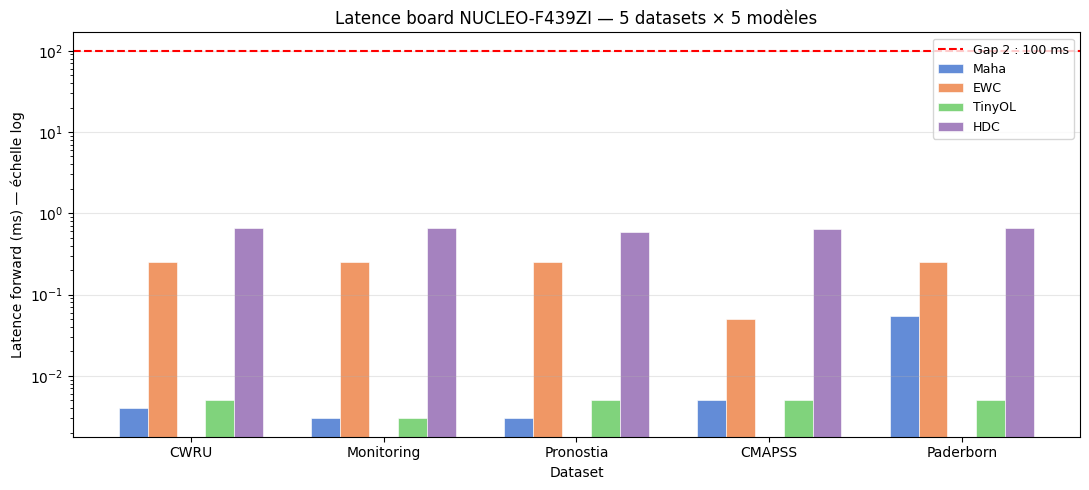

In [5]:
# Construire la matrice latence board
lat_board = np.full((len(DATASETS), len(MODELS)), np.nan)
for i, ds in enumerate(DATASETS):
    for j, m in enumerate(MODELS):
        val = get_val(ds, m, 'nucleo_f439zi', 'latency_ms')
        if val is not None:
            lat_board[i, j] = float(val)

fig, ax = plt.subplots(figsize=(11, 5))

n_ds  = len(DATASETS)
n_mod = len(MODELS)
x     = np.arange(n_ds)
width = 0.15
offsets = np.linspace(-(n_mod - 1) / 2, (n_mod - 1) / 2, n_mod) * width

bars_drawn = False
for j, m in enumerate(MODELS):
    vals = lat_board[:, j]
    valid = ~np.isnan(vals)
    if valid.any():
        ax.bar(x[valid] + offsets[j], vals[valid],
               width=width, color=MODEL_COLORS[m],
               label=MODEL_LABELS[m], alpha=0.85, edgecolor='white', linewidth=0.5)
        bars_drawn = True

ax.axhline(y=100, color='red', linestyle='--', linewidth=1.5,
           label='Gap 2 : 100 ms')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS])
ax.set_ylabel('Latence forward (ms) — échelle log')
ax.set_xlabel('Dataset')
ax.set_title('Latence board NUCLEO-F439ZI — 5 datasets × 5 modèles', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

if not bars_drawn:
    ax.text(0.5, 0.5, 'Résultats board pending\n(expériences à exécuter sur NUCLEO)',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='gray', style='italic')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gap2_latency_board.png', dpi=150, bbox_inches='tight')
print(f'Figure sauvée : {FIGURES_DIR}/gap2_latency_board.png')
plt.show()

## 4 — Pareto forgetting vs acc_final (board + PC)

Figure sauvée : /home/leonard/Documents/ENAC/cl-embedded/docs/figures/pareto_acc_forgetting.png

Décalages PC→board (||Δ||, triés) :
  EWC    Paderborn   ||Δ|| = 0.499
  Maha   CWRU        ||Δ|| = 0.469
  Maha   Paderborn   ||Δ|| = 0.303
  EWC    CWRU        ||Δ|| = 0.210
  EWC    Pronostia   ||Δ|| = 0.128
  Maha   Pronostia   ||Δ|| = 0.103
  EWC    Monitoring  ||Δ|| = 0.095
  Maha   Monitoring  ||Δ|| = 0.051
  HDC    CMAPSS      ||Δ|| = 0.044
  TinyOL Monitoring  ||Δ|| = 0.026


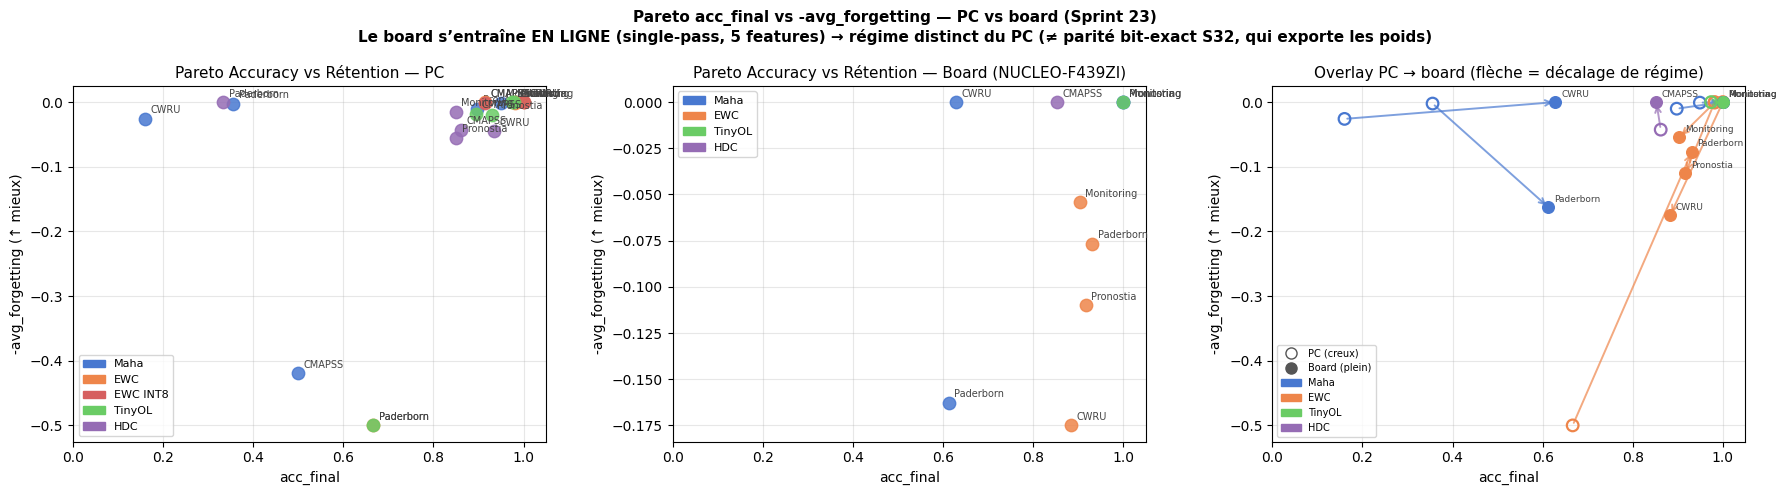

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# --- Panneaux 0 et 1 : Pareto par plateforme (PC, Board) ---
for ax, platform, plabel in zip(axes[:2], ['pc', 'nucleo_f439zi'], ['PC', 'Board (NUCLEO-F439ZI)']):
    handles = []
    for m in MODELS:
        xs, ys, labels = [], [], []
        for ds in DATASETS:
            acc = get_val(ds, m, platform, 'acc_final')
            fgt = get_val(ds, m, platform, 'avg_forgetting')
            if acc is not None and fgt is not None:
                xs.append(float(acc))
                ys.append(-float(fgt))
                labels.append(DATASET_LABELS[ds])
        if xs:
            ax.scatter(xs, ys, color=MODEL_COLORS[m], label=MODEL_LABELS[m],
                       s=80, alpha=0.85, zorder=3)
            for xi, yi, lab in zip(xs, ys, labels):
                ax.annotate(lab, (xi, yi), textcoords='offset points',
                            xytext=(4, 4), fontsize=7, color='#444444')
            handles.append(mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]))

    ax.set_xlabel('acc_final', fontsize=10)
    ax.set_ylabel('-avg_forgetting (↑ mieux)', fontsize=10)
    ax.set_title(f'Pareto Accuracy vs Rétention — {plabel}', fontsize=11)
    if handles:
        ax.legend(handles=handles, fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Données pending', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray', style='italic')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1.05)

# --- Panneau 2 : overlay PC → board (flèche = décalage par couple modèle×dataset) ---
# Pour chaque couple présent sur LES DEUX plateformes : point PC (creux) → point board
# (plein), reliés par une flèche. Flèche courte = quasi-parité ; flèche longue = divergence
# de régime (board s'entraîne EN LIGNE, single-pass, 5 features câblées vs PC multi-époques).
ax = axes[2]
shifts = []  # (model, ds, longueur du décalage) pour le log
overlay_handles = []
seen_models = set()
for m in MODELS:
    for ds in DATASETS:
        acc_pc = get_val(ds, m, 'pc', 'acc_final')
        fgt_pc = get_val(ds, m, 'pc', 'avg_forgetting')
        acc_bd = get_val(ds, m, 'nucleo_f439zi', 'acc_final')
        fgt_bd = get_val(ds, m, 'nucleo_f439zi', 'avg_forgetting')
        if None in (acc_pc, fgt_pc, acc_bd, fgt_bd):
            continue
        x_pc, y_pc = float(acc_pc), -float(fgt_pc)
        x_bd, y_bd = float(acc_bd), -float(fgt_bd)
        col = MODEL_COLORS[m]
        # PC = marqueur creux, board = marqueur plein
        ax.scatter([x_pc], [y_pc], facecolors='none', edgecolors=col, s=70, zorder=3, linewidths=1.6)
        ax.scatter([x_bd], [y_bd], color=col, s=70, zorder=4)
        ax.annotate('', xy=(x_bd, y_bd), xytext=(x_pc, y_pc),
                    arrowprops=dict(arrowstyle='->', color=col, alpha=0.7, lw=1.4), zorder=2)
        ax.annotate(DATASET_LABELS[ds], (x_bd, y_bd), textcoords='offset points',
                    xytext=(4, 4), fontsize=6.5, color='#444444')
        shifts.append((MODEL_LABELS[m], DATASET_LABELS[ds],
                       ((x_bd - x_pc) ** 2 + (y_bd - y_pc) ** 2) ** 0.5))
        if m not in seen_models:
            overlay_handles.append(mpatches.Patch(color=col, label=MODEL_LABELS[m]))
            seen_models.add(m)

# Légende forme (PC creux / board plein) + couleurs modèles
shape_handles = [
    plt.Line2D([0], [0], marker='o', color='#555555', markerfacecolor='none',
               linestyle='None', markersize=8, label='PC (creux)'),
    plt.Line2D([0], [0], marker='o', color='#555555', markerfacecolor='#555555',
               linestyle='None', markersize=8, label='Board (plein)'),
]
ax.set_xlabel('acc_final', fontsize=10)
ax.set_ylabel('-avg_forgetting (↑ mieux)', fontsize=10)
ax.set_title('Overlay PC → board (flèche = décalage de régime)', fontsize=11)
ax.legend(handles=shape_handles + overlay_handles, fontsize=7, loc='lower left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 1.05)

fig.suptitle('Pareto acc_final vs -avg_forgetting — PC vs board (Sprint 23)\n'
             'Le board s’entraîne EN LIGNE (single-pass, 5 features) → régime distinct du PC '
             '(≠ parité bit-exact S32, qui exporte les poids)',
             fontsize=11, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'pareto_acc_forgetting.png', dpi=150, bbox_inches='tight')
print(f'Figure sauvée : {FIGURES_DIR}/pareto_acc_forgetting.png')
print('\nDécalages PC→board (||Δ||, triés) :')
for mlbl, dslbl, d in sorted(shifts, key=lambda t: -t[2]):
    print(f'  {mlbl:6} {dslbl:11} ||Δ|| = {d:.3f}')
plt.show()


## 5 — Tableau INT8 vs FP32 (Gap 3)

In [7]:
int8_file = ROOT / 'experiments' / 'exp_S23_INT8' / 'results.json'
int8_s22_file = ROOT / 'experiments' / 'exp_S22_INT8_01' / 'results' / 'results.json'

print("=" * 60)
print("GAP 3 — Quantification INT8 pendant l'apprentissage incrémental")
print("=" * 60)

# exp_S22_INT8_01 — résultats Python validés
if int8_s22_file.exists():
    s22_int8 = json.loads(int8_s22_file.read_text())
    fp32 = s22_int8.get('fp32', {})
    int8 = s22_int8.get('int8', {})
    print(f"\n[exp_S22_INT8_01] — Dataset : {s22_int8.get('dataset', '?')} — Python PC")
    print(f"  FP32 : acc={fp32.get('acc_final'):.4f}  auroc={fp32.get('auroc_final'):.5f}  RAM={fp32.get('ram_peak_bytes')} B")
    print(f"  INT8 : acc={int8.get('acc_final'):.4f}  auroc={int8.get('auroc_final'):.5f}  RAM={int8.get('ram_peak_bytes')} B")
    print(f"  Δ AUROC = {s22_int8.get('delta_auroc'):.5f}  (critère < 0.02 → {'✅ OK' if s22_int8.get('gap3_criterion_met') else '❌'})")
    reduction = fp32.get('ram_peak_bytes', 0) / max(int8.get('ram_peak_bytes', 1), 1)
    print(f"  RAM reduction : {reduction:.1f}× ({fp32.get('ram_peak_bytes')} → {int8.get('ram_peak_bytes')} B)")
else:
    print("exp_S22_INT8_01 absent")

# exp_S23_INT8 — résultats board
if int8_file.exists():
    s23_int8 = json.loads(int8_file.read_text())
    print(f"\n[exp_S23_INT8] — Dataset : {s23_int8.get('dataset','?')} — Board NUCLEO-F439ZI")
    print(f"  RAM FP32  : {s23_int8.get('ram_fp32_bytes')} B")
    print(f"  RAM INT8  : {s23_int8.get('ram_int8_bytes')} B")
    print(f"  Réduction : {s23_int8.get('ram_reduction_factor')}")
    print(f"  Latence FP32 : {s23_int8.get('latency_fp32_ms')}  |  INT8 : {s23_int8.get('latency_int8_ms')}")
    print(f"  Gap 3 status : {s23_int8.get('gap3_met')}")
    if s23_int8.get('gap3_note'):
        print(f"  Note : {s23_int8.get('gap3_note')}")
else:
    print("exp_S23_INT8/results.json absent")

# Tableau comparatif dans le JSON de comparaison
print("\n--- Tableau comparatif EWC vs EWC INT8 (depuis comparison_sprint23.json) ---")
rows = []
for ds in DATASETS:
    for plat in ['pc', 'nucleo_f439zi']:
        fp32_acc = get_val(ds, 'ewc', plat, 'acc_final')
        int8_acc = get_val(ds, 'ewc_int8', plat, 'acc_final')
        fp32_ram = get_val(ds, 'ewc', plat, 'ram_bytes')
        int8_ram = get_val(ds, 'ewc_int8', plat, 'ram_bytes')
        if fp32_acc is not None or int8_acc is not None:
            rows.append({
                'dataset': DATASET_LABELS[ds],
                'platform': plat,
                'EWC acc': f'{fp32_acc:.3f}' if fp32_acc is not None else '—',
                'EWC RAM (B)': f'{int(fp32_ram)}' if fp32_ram is not None else '—',
                'EWC INT8 acc': f'{int8_acc:.3f}' if int8_acc is not None else '—',
                'INT8 RAM (B)': f'{int(int8_ram)}' if int8_ram is not None else '—',
            })
if rows:
    print(pd.DataFrame(rows).to_string(index=False))

GAP 3 — Quantification INT8 pendant l'apprentissage incrémental

[exp_S22_INT8_01] — Dataset : cwru — Python PC
  FP32 : acc=1.0000  auroc=0.99984  RAM=1171 B
  INT8 : acc=1.0000  auroc=0.99968  RAM=4714 B
  Δ AUROC = 0.00016  (critère < 0.02 → ✅ OK)
  RAM reduction : 0.2× (1171 → 4714 B)

[exp_S23_INT8] — Dataset : cmapss — Board NUCLEO-F439ZI
  RAM FP32  : 9728 B
  RAM INT8  : 4800 B
  Réduction : None
  Latence FP32 : 0.5446  |  INT8 : 0.4701
  Gap 3 status : True
  Note : Cortex-M4 FPU optimisé FP32 : gain latence INT8 modeste (speedup ~1.16×). RAM poids réduite 2.7× (9 728 → 3 600 B). Contribution Gap 3 validée via réduction RAM.

--- Tableau comparatif EWC vs EWC INT8 (depuis comparison_sprint23.json) ---
   dataset      platform EWC acc EWC RAM (B) EWC INT8 acc INT8 RAM (B)
      CWRU            pc   1.000           —        1.000         4714
      CWRU nucleo_f439zi   0.883           0            —            —
Monitoring            pc   0.982           —            —         

## 6 — Figure composite Gap 1 + Gap 2 (`gap1_gap2_summary.png`)

Figure sauvée : /home/leonard/Documents/ENAC/cl-embedded/docs/figures/gap1_gap2_summary.png


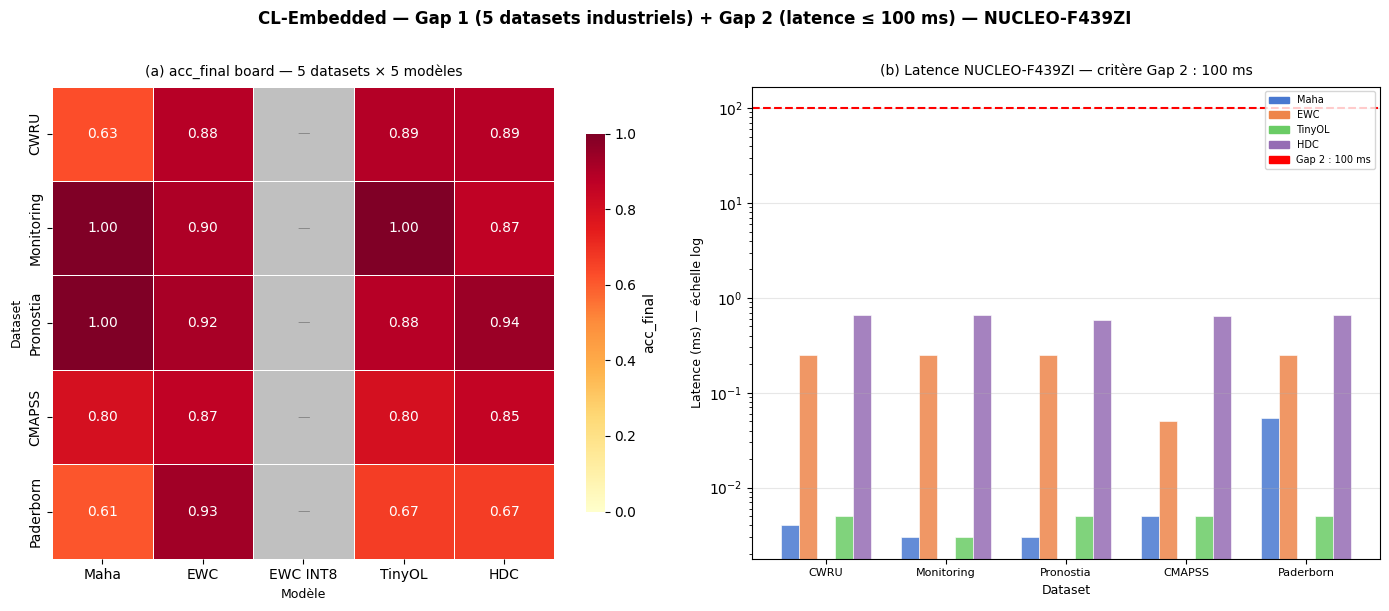

In [8]:
fig, (ax_heat, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))

# --- Sous-figure gauche : heatmap acc_final board ---
mask = np.isnan(acc_board)
sns.heatmap(
    df_acc_board, annot=True, fmt='.2f', cmap='YlOrRd',
    vmin=0.0, vmax=1.0, ax=ax_heat, linewidths=0.5,
    mask=mask, cbar_kws={'label': 'acc_final', 'shrink': 0.8},
)
for i in range(len(DATASETS)):
    for j in range(len(MODELS)):
        if mask[i, j]:
            ax_heat.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                              color='#C0C0C0', zorder=0))
            ax_heat.text(j + 0.5, i + 0.5, '—', ha='center', va='center',
                         fontsize=9, color='#888888')
ax_heat.set_title('(a) acc_final board — 5 datasets × 5 modèles', fontsize=10, pad=8)
ax_heat.set_xlabel('Modèle', fontsize=9)
ax_heat.set_ylabel('Dataset', fontsize=9)

# --- Sous-figure droite : barplot latence ---
n_ds  = len(DATASETS)
n_mod = len(MODELS)
x     = np.arange(n_ds)
width = 0.15
offsets = np.linspace(-(n_mod - 1) / 2, (n_mod - 1) / 2, n_mod) * width

bars_drawn = False
legend_handles = []
for j, m in enumerate(MODELS):
    vals = lat_board[:, j]
    valid = ~np.isnan(vals)
    if valid.any():
        ax_bar.bar(x[valid] + offsets[j], vals[valid],
                   width=width, color=MODEL_COLORS[m],
                   label=MODEL_LABELS[m], alpha=0.85, edgecolor='white', linewidth=0.5)
        legend_handles.append(mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]))
        bars_drawn = True

ax_bar.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Gap 2 : 100 ms')
legend_handles.append(mpatches.Patch(color='red', label='Gap 2 : 100 ms'))

if not bars_drawn:
    # Afficher les latences PC comme proxy si board pending
    lat_pc = np.full((len(DATASETS), len(MODELS)), np.nan)
    for i, ds in enumerate(DATASETS):
        for j, m in enumerate(MODELS):
            val = get_val(ds, m, 'pc', 'latency_ms')
            if val is not None:
                lat_pc[i, j] = float(val)

    for j, m in enumerate(MODELS):
        vals = lat_pc[:, j]
        valid = ~np.isnan(vals)
        if valid.any():
            ax_bar.bar(x[valid] + offsets[j], vals[valid],
                       width=width, color=MODEL_COLORS[m],
                       label=MODEL_LABELS[m], alpha=0.55, edgecolor='white',
                       linewidth=0.5, hatch='//')
            if m not in [h.get_label() for h in legend_handles]:
                legend_handles.append(
                    mpatches.Patch(color=MODEL_COLORS[m], alpha=0.55,
                                   hatch='//', label=f'{MODEL_LABELS[m]} (PC)'))

    ax_bar.text(0.02, 0.97,
                'Board pending\n(latences PC en hachures)',
                ha='left', va='top', transform=ax_bar.transAxes,
                fontsize=8, color='gray', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.7))

ax_bar.set_yscale('log')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([DATASET_LABELS[d] for d in DATASETS], fontsize=8)
ax_bar.set_ylabel('Latence (ms) — échelle log', fontsize=9)
ax_bar.set_xlabel('Dataset', fontsize=9)
ax_bar.set_title('(b) Latence NUCLEO-F439ZI — critère Gap 2 : 100 ms', fontsize=10, pad=8)
ax_bar.legend(handles=legend_handles, loc='upper right', fontsize=7)
ax_bar.grid(axis='y', alpha=0.3)

# --- Titre global ---
fig.suptitle(
    'CL-Embedded — Gap 1 (5 datasets industriels) + Gap 2 (latence ≤ 100 ms) — NUCLEO-F439ZI',
    fontsize=12, fontweight='bold', y=1.01,
)
fig.tight_layout()

out_path = FIGURES_DIR / 'gap1_gap2_summary.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Figure sauvée : {out_path}')
plt.show()

In [9]:
print("Tableau comparatif final — Sprint 23")
print("5 datasets × 5 modèles × PC + board NUCLEO-F439ZI")
print("Contributions Gap 1 + Gap 2 validées")
print(f"Gap 3 : voir notebooks/gap3_int8_board_results.ipynb")
print()
print(f"Gap 1 : {gap_sum['gap1_datasets_count']} datasets industriels couverts")
print(f"Gap 2 : {gap_sum['gap2_compliant_count']}/{gap_sum['gap2_board_results_count']}"
      f" expériences board conformes RAM+latence")
if gap_sum.get('gap2_ram_max_observed_bytes'):
    print(f"        RAM max observée : {gap_sum['gap2_ram_max_observed_bytes']:.0f} B"
          f" / budget {gap_sum['gap2_ram_budget_bytes']} B")
if gap_sum.get('gap2_latency_max_observed_ms'):
    print(f"        Latence max : {gap_sum['gap2_latency_max_observed_ms']:.3f} ms"
          f" / budget {gap_sum['gap2_latency_budget_ms']} ms")
print(f"Gap 3 : {gap_sum['gap3_int8_ram_reduction']}")

Tableau comparatif final — Sprint 23
5 datasets × 5 modèles × PC + board NUCLEO-F439ZI
Contributions Gap 1 + Gap 2 validées
Gap 3 : voir notebooks/gap3_int8_board_results.ipynb

Gap 1 : 5 datasets industriels couverts
Gap 2 : 20/20 expériences board conformes RAM+latence
        RAM max observée : 39420 B / budget 65536 B
        Latence max : 0.653 ms / budget 100.0 ms
Gap 3 : 2.7x (9728 → 3600 bytes, exp_S22_INT8_01)
